In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [2]:
FILE_PATH = 'Data/advertising.csv'

In [3]:
df = pd.read_csv(FILE_PATH)
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


# Lấy thông tin cơ bản của bộ dữ liệu

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [5]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [6]:
X = df.iloc[:,:-1]
X.head()

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [7]:
y = df.iloc[:,-1]
y

0      22.1
1      10.4
2      12.0
3      16.5
4      17.9
       ... 
195     7.6
196    14.0
197    14.8
198    25.5
199    18.4
Name: Sales, Length: 200, dtype: float64

In [8]:
Scaler = MinMaxScaler()
X = Scaler.fit_transform(X)
X[:5]

array([[0.77578627, 0.76209677, 0.60598065],
       [0.1481231 , 0.79233871, 0.39401935],
       [0.0557998 , 0.92540323, 0.60686016],
       [0.50997633, 0.83266129, 0.51187335],
       [0.60906324, 0.21774194, 0.51099384]])

In [9]:
y = y.to_numpy()
y

array([22.1, 10.4, 12. , 16.5, 17.9,  7.2, 11.8, 13.2,  4.8, 15.6, 12.6,
       17.4,  9.2, 13.7, 19. , 22.4, 12.5, 24.4, 11.3, 14.6, 18. , 17.5,
        5.6, 20.5,  9.7, 17. , 15. , 20.9, 18.9, 10.5, 21.4, 11.9, 13.2,
       17.4, 11.9, 17.8, 25.4, 14.7, 10.1, 21.5, 16.6, 17.1, 20.7, 17.9,
        8.5, 16.1, 10.6, 23.2, 19.8,  9.7, 16.4, 10.7, 22.6, 21.2, 20.2,
       23.7,  5.5, 13.2, 23.8, 18.4,  8.1, 24.2, 20.7, 14. , 16. , 11.3,
       11. , 13.4, 18.9, 22.3, 18.3, 12.4,  8.8, 11. , 17. ,  8.7,  6.9,
       14.2,  5.3, 11. , 11.8, 17.3, 11.3, 13.6, 21.7, 20.2, 12. , 16. ,
       12.9, 16.7, 14. ,  7.3, 19.4, 22.2, 11.5, 16.9, 16.7, 20.5, 25.4,
       17.2, 16.7, 23.8, 19.8, 19.7, 20.7, 15. ,  7.2, 12. ,  5.3, 19.8,
       18.4, 21.8, 17.1, 20.9, 14.6, 12.6, 12.2,  9.4, 15.9,  6.6, 15.5,
        7. , 16.6, 15.2, 19.7, 10.6,  6.6, 11.9, 24.7,  9.7,  1.6, 17.7,
        5.7, 19.6, 10.8, 11.6,  9.5, 20.8,  9.6, 20.7, 10.9, 19.2, 20.1,
       10.4, 12.3, 10.3, 18.2, 25.4, 10.9, 10.1, 16

# Linear Regression with mini batching final

In [10]:
# Nên chuyển về vector dạng cột -> chuyển về dạng ma trận N dòng 1 cột -> Chuẩn với toán học
class LinearRegression:
    def __init__(self,lr = 0.01, batch_size = 1, epochs = 100, shuffle = False):
        self.lr = lr # learning rate
        self.batch_size = batch_size # num sample to training
        self.epochs = epochs # epoch: Number of times the model is learned in all data
        self.shuffle = shuffle # allow shuffle data in each epoch
        self.w = None
        self.Nfeature = None # number of feature of data train
        self.Nsample = None # number of sample of data train
        self.Losses = [] # List of loss of each epoch
    def checkDim(self,X):
        if X.ndim == 1:
            raise ValueError("X must be 2 Dimensional")
        return 1
    # add feature have value = 1 on head each sample
    def addfeature1(self,X):
        if self.checkDim(X):
            if X.shape[1] == self.Nfeature + 1: return X
            else:
                feature1 = np.ones(X.shape[0]).reshape(-1,1)
                return np.concatenate((feature1,X),axis = 1)
    # function predict
    def predict(self,X):
        X = self.addfeature1(X)
        return X@self.w

    # Compute Loss
    def compute_loss(self,y_pred,y):
        return np.mean((y_pred-y)**2)/(2*y_pred.shape[0])

    # Compute gradient Loss with w
    # Loss = 1/2m *(y_pred-y)^2 -> m is bacth_size
    def dL_dw(self,y_pred,y,X):
        return X.T@(y_pred - y)*1/X.shape[0] # / for X.shape[0] because the sample of X != batch_size

    # function training model
    def fit(self,X,y):
        self.Nsample, self.Nfeature = X.shape
        # add feature 1 for X
        X = self.addfeature1(X)
        y = y.reshape(-1,1)
        self.w = np.random.uniform(-1,1,size= self.Nfeature+1).reshape(-1,1)# w is matrix have shape (Nfeatur,1)
        data_train = np.concatenate((X,y),axis = 1)
        for epoch in range(self.epochs):
            if self.shuffle: np.random.shuffle(data_train)
            Loss = [] # Loss of 1 epoch
            for i in range(0,self.Nsample,self.batch_size):
                batch = data_train[i:i+self.batch_size]
                X_train, ytrain = batch[:,:-1], batch[:,-1].reshape(-1,1)
                y_pred = self.predict(X_train)
                loss = self.compute_loss(y_pred,ytrain)
                Loss.append(loss) # append loss of each batch
                dL_dw = self.dL_dw(y_pred,ytrain,X_train)
                self.w -= self.lr*dL_dw
            self.Losses.append(sum(Loss)/len(Loss))
            print(f"epoch: {epoch+1:<5} ====== Loss = {self.Losses[-1].item():<10.4f} =============== w = {str(self.w.reshape(1,-1)):<20}")

In [11]:
rg = LinearRegression(batch_size=128,shuffle=True,epochs=200)

In [12]:
rg.fit(X,y)

epoch: 1     ====== Loss = 1.2214     =============== w = [[ 1.27579663 -0.60089944  0.80683422 -0.03169456]]
epoch: 2     ====== Loss = 1.1270     =============== w = [[ 1.54719369 -0.43870276  0.94182764  0.04237981]]
epoch: 3     ====== Loss = 1.1084     =============== w = [[ 1.81275344 -0.27899733  1.07620875  0.11441223]]
epoch: 4     ====== Loss = 1.0384     =============== w = [[ 2.06942386 -0.12380936  1.2066834   0.18549504]]
epoch: 5     ====== Loss = 1.0390     =============== w = [[2.32255431 0.03088501 1.33625439 0.2552807 ]]
epoch: 6     ====== Loss = 0.9703     =============== w = [[2.56545358 0.182201   1.45862813 0.32288809]]
epoch: 7     ====== Loss = 0.8966     =============== w = [[2.79982221 0.32682307 1.57763315 0.38927709]]
epoch: 8     ====== Loss = 0.8190     =============== w = [[3.02477281 0.46513655 1.69186116 0.45064901]]
epoch: 9     ====== Loss = 0.8182     =============== w = [[3.24600547 0.60293649 1.80458442 0.51298183]]
epoch: 10    ====== Loss = 0.6

Vẽ Loss của mô hình sau khi huấn luyện mô hình

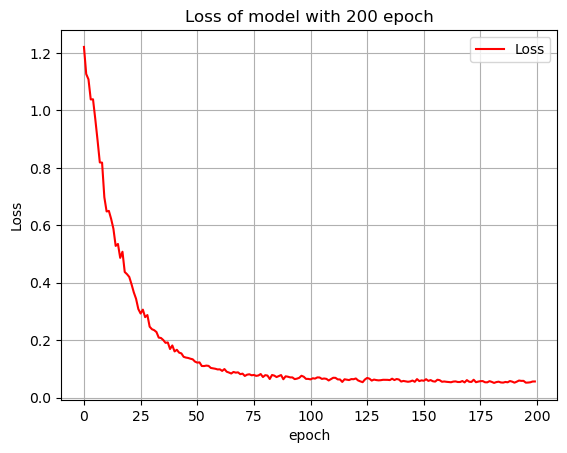

In [13]:
plt.title(f"Loss of model with {rg.epochs} epoch")
plt.xlabel("epoch")
plt.ylabel("Loss")
plt.plot(rg.Losses,'r',label = 'Loss')
plt.legend()
plt.grid()
plt.show()
